<p style ="text-align:center">
    <img src="https://raw.githubusercontent.com/EduPekUfpr/PythonProject/refs/heads/main/Images/BannerUFPR.png" width="700" alt="PPGOLD/PPGMNE Python:INTRO"  />
</p>

## Prof. Eduardo Pécora, Ph.D.

# **Pandas: Preenchendo Ausentes com `interpolate()`**

Neste notebook cobriremos:

1. [Por que `interpolate()` precisa de dados ordenados](#why)
2. [Interpolação linear básica](#linear)
3. [Outros métodos de interpolação](#methods)
4. [Limitações: extremos da série e `limit`](#limits)
5. [Exercício](#exercicio)

<a id="why"></a>
## Por que este método é diferente de `dropna()` e `fillna()`

No notebook de Valores Ausentes vimos duas estratégias: **remover** linhas/colunas (`dropna()`) e **substituir** por um valor fixo ou estatístico (`fillna()`). Ambas ignoram a ordem das linhas — não importa se uma linha está antes ou depois da outra.

O método `interpolate()` é diferente: ele estima o valor ausente **a partir dos vizinhos mais próximos**, assumindo que existe uma progressão lógica entre uma linha e a seguinte. Isso só faz sentido quando o DataFrame/Series tem uma **ordem real** — o exemplo mais comum é uma **série temporal** (dados organizados por dia, mês, hora etc.), como as que usaremos no curso de previsão de demanda.

⚠️ Se você aplicar `interpolate()` em dados sem ordem lógica (como uma lista de jogadores em ordem alfabética), o resultado é preenchido com base em uma vizinhança **acidental**, sem significado real.

<a id="linear"></a>
## Interpolação linear básica

Vamos criar uma série temporal fictícia — por exemplo, a temperatura média diária registrada por um sensor que falhou em alguns dias.

In [7]:
import pandas as pd
import numpy as np

datas = pd.date_range('2024-01-01', periods=10, freq='D')
temperatura = pd.Series([18, 19, np.nan, np.nan, 23, 24, np.nan, 21, 20, 19], index=datas, name='Temperatura (°C)')
temperatura

,Temperatura (°C)
2024-01-01,18.0
2024-01-02,19.0
2024-01-03,NaN
2024-01-04,NaN
2024-01-05,23.0
2024-01-06,24.0
2024-01-07,NaN
2024-01-08,21.0
2024-01-09,20.0
2024-01-10,19.0


Por padrão, `interpolate()` usa o método `'linear'`: para cada trecho de ausentes, traça uma reta entre o último valor válido antes e o primeiro valor válido depois, e distribui os valores igualmente ao longo do trecho.

In [8]:
temperatura_interpolada = temperatura.interpolate()
temperatura_interpolada

,Temperatura (°C)
2024-01-01,18.000000
2024-01-02,19.000000
2024-01-03,20.333333
2024-01-04,21.666667
2024-01-05,23.000000
2024-01-06,24.000000
2024-01-07,22.500000
2024-01-08,21.000000
2024-01-09,20.000000
2024-01-10,19.000000


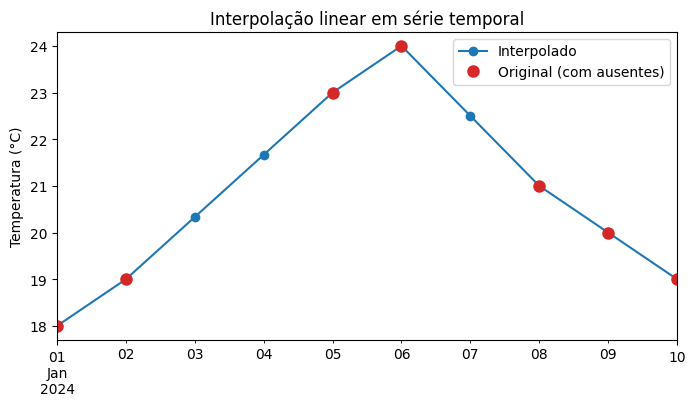

In [9]:
# Visualizando: pontos originais vs. interpolados
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
temperatura_interpolada.plot(ax=ax, marker='o', label='Interpolado', color='tab:blue')
temperatura.plot(ax=ax, marker='o', linestyle='none', label='Original (com ausentes)', color='tab:red', markersize=8)
ax.set_title('Interpolação linear em série temporal')
ax.set_ylabel('Temperatura (°C)')
ax.legend()
plt.show()

<a id="methods"></a>
## Outros métodos de interpolação

`'linear'` é o padrão, mas existem outros métodos para diferentes formatos de curva. Alguns exemplos:

- `'nearest'`: copia o valor válido mais próximo (sem criar uma média)
- `'polynomial'` (com `order=N`): ajusta uma curva polinomial
- `'time'`: como `'linear'`, mas leva em conta o espaçamento real das datas (útil quando os intervalos não são regulares)

Vale sempre comparar visualmente os métodos antes de escolher — cada um assume uma forma diferente para os dados ausentes.

In [15]:
comparacao = pd.DataFrame({
    'original': temperatura,
    'linear': temperatura.interpolate(method='linear'),
    'nearest': temperatura.interpolate(method='nearest'),
    'polynomial_2': temperatura.interpolate(method='polynomial', order=2),
    'polynomial_3': temperatura.interpolate(method='polynomial', order=3)
})
comparacao

,original,linear,nearest,polynomial_2,polynomial_3
2024-01-01,18.0,18.000000,18.0,18.000000,18.000000
2024-01-02,19.0,19.000000,19.0,19.000000,19.000000
2024-01-03,NaN,20.333333,19.0,20.222384,20.199615
2024-01-04,NaN,21.666667,23.0,21.630006,21.549422
2024-01-05,23.0,23.000000,23.0,23.000000,23.000000
2024-01-06,24.0,24.000000,24.0,24.000000,24.000000
2024-01-07,NaN,22.500000,24.0,22.858684,22.876605
2024-01-08,21.0,21.000000,21.0,21.000000,21.000000
2024-01-09,20.0,20.000000,20.0,20.000000,20.000000
2024-01-10,19.0,19.000000,19.0,19.000000,19.000000


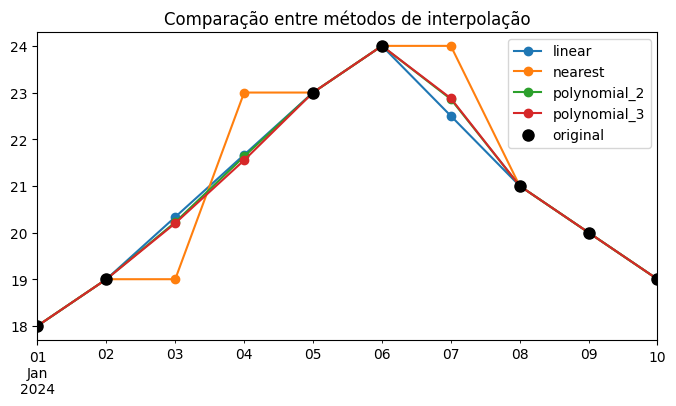

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
comparacao[['linear', 'nearest', 'polynomial_2','polynomial_3']].plot(ax=ax, marker='o')
comparacao['original'].plot(ax=ax, marker='o', linestyle='none', color='black', markersize=8, label='original')
ax.set_title('Comparação entre métodos de interpolação')
ax.legend()
plt.show()

<a id="limits"></a>
## Limitações: extremos da série e o parâmetro `limit`

Um ponto importante: `interpolate()` **não consegue preencher ausentes nas pontas** da série (não há vizinho de um dos lados para calcular a reta). Nesses casos, o valor continua `NaN`, a menos que você use `limit_direction='both'` (que aí passa a extrapolar, com menos confiabilidade).

Também é possível limitar **quantos ausentes consecutivos** o método preenche, com o parâmetro `limit` — útil para evitar preencher uma falha longa do sensor com uma linha reta muito extensa e pouco confiável.

In [19]:
# Série com ausente na ponta
temperatura2 = pd.Series([np.nan, 19, 20, np.nan, np.nan, np.nan, np.nan, np.nan, 24, 25], index=datas, name='Temperatura (°C)')

print('Padrão (não preenche a ponta, preenche o buraco inteiro):')
print(temperatura2.interpolate())

print('\nCom limit=2 (só preenche até 2 ausentes seguidos):')
print(temperatura2.interpolate(limit=2))

print('\nCom limit_direction Preenche todos:')
print(temperatura2.interpolate(limit_direction='both'))

Padrão (não preenche a ponta, preenche o buraco inteiro):
2024-01-01          NaN
2024-01-02    19.000000
2024-01-03    20.000000
2024-01-04    20.666667
2024-01-05    21.333333
2024-01-06    22.000000
2024-01-07    22.666667
2024-01-08    23.333333
2024-01-09    24.000000
2024-01-10    25.000000
Freq: D, Name: Temperatura (°C), dtype: float64

Com limit=2 (só preenche até 2 ausentes seguidos):
2024-01-01          NaN
2024-01-02    19.000000
2024-01-03    20.000000
2024-01-04    20.666667
2024-01-05    21.333333
2024-01-06          NaN
2024-01-07          NaN
2024-01-08          NaN
2024-01-09    24.000000
2024-01-10    25.000000
Freq: D, Name: Temperatura (°C), dtype: float64

Com limit_direction Preenche todos:
2024-01-01    19.000000
2024-01-02    19.000000
2024-01-03    20.000000
2024-01-04    20.666667
2024-01-05    21.333333
2024-01-06    22.000000
2024-01-07    22.666667
2024-01-08    23.333333
2024-01-09    24.000000
2024-01-10    25.000000
Freq: D, Name: Temperatura (°C), dtyp

<a id="exercicio"></a>
## Exercício

Crie sua própria série temporal fictícia (pode ser vendas diárias, nível de estoque, número de visitantes, etc.), com pelo menos 12 pontos e ao menos dois ausentes consecutivos.

1. Preencha os ausentes com `interpolate()` usando o método padrão.
2. Compare o resultado com pelo menos um outro método (`'nearest'` ou `'polynomial'`).
3. Em uma célula de texto, explique **qual método você escolheria** para o seu cenário e por quê — não existe uma única resposta certa, o importante é justificar com base no comportamento esperado dos seus dados.

## Fique Conectado

- [![YouTube](https://img.icons8.com/?size=40&id=19318&format=png&color=000000)](https://www.youtube.com/@LigaDataScience/videos)  
  Explore nossos vídeos educacionais e webinars sobre ciência de dados, machine learning e inteligência artificial. Inscreva-se para não perder nenhuma atualização!

- [![LinkedIn](https://img.icons8.com/?size=40&id=13930&format=png&color=000000)](https://www.linkedin.com/company/liga-data-science-ufpr/)  
  Siga-nos no LinkedIn para as últimas novidades, oportunidades de carreira e networking profissional no campo da ciência de dados.

- [![Instagram](https://img.icons8.com/?size=40&id=32323&format=png&color=000000)](https://www.instagram.com/ligadatascience/)  
  Confira nosso Instagram para conteúdos dos bastidores, destaques de eventos e o dia a dia da Liga Data Science. Faça parte da nossa jornada!
  
  ## Autores

<a href="https://www.linkedin.com/in/eduardopecora/" target="_blank">Eduardo Pecora</a>

## Log de modificações

| Data | Versão | Modificado por | Descrição |
| ----------------- | ------- | ---------- | ---------------------------------- |
| 10-08-2026 | 1.0 | Claude (a pedido de Eduardo Pécora) | Notebook inicial, desmembrado do material de Valores Ausentes |
| 10-08-2026 | 1.1 | Pécora | Revisão |

<hr>

## <h3 align="center"> (c) Liga Data Science/ UFPR 2026. All rights reserved. <h3/>